# NumPy Mini Project — Student Performance Analyzer

A very small project built only from the basic NumPy and Matplotlib ideas used in the supplied course notebooks.

We will take a tiny table of student marks and use NumPy to:

- work with arrays and shapes
- calculate averages and standard deviation
- use slicing and `axis`
- use a dot product / `@` for a weighted score
- find the top student
- visualize the data with Matplotlib

**No machine-learning framework. No external dataset. No advanced NumPy tricks.**

The goal is not to build a sophisticated application. The goal is to make the NumPy operations feel natural.


## 1. Imports and data

We have six students and three subjects.

Rows = students  
Columns = subjects


In [1]:
import numpy as np
import matplotlib.pyplot as plt

students = np.array(["Ali", "Sara", "Ahmed", "Ayesha", "Hamza", "Zara"])

scores = np.array([
    [78, 85, 82],
    [92, 88, 95],
    [65, 72, 70],
    [84, 79, 88],
    [71, 68, 75],
    [95, 91, 89]
])

subjects = np.array(["Python", "NumPy", "Statistics"])

print("Scores:")
print(scores)
print()
print("Shape:", scores.shape)
print("Number of dimensions:", scores.ndim)
print("Total values:", scores.size)


Scores:
[[78 85 82]
 [92 88 95]
 [65 72 70]
 [84 79 88]
 [71 68 75]
 [95 91 89]]

Shape: (6, 3)
Number of dimensions: 2
Total values: 18


## 2. Look at the array


In [2]:
print("Ali's scores:", scores[0, :])
print("Python scores:", scores[:, 0])
print("First three students:")
print(scores[:3, :])
print()
print("Ali's NumPy score:", scores[0, 1])


Ali's scores: [78 85 82]
Python scores: [78 92 65 84 71 95]
First three students:
[[78 85 82]
 [92 88 95]
 [65 72 70]]

Ali's NumPy score: 85


## 3. Basic statistics


In [3]:
student_mean = np.mean(scores, axis=1)
subject_mean = np.mean(scores, axis=0)
subject_std = np.std(scores, axis=0)

print("Average for each student:")
print(np.round(student_mean, 2))

print()
print("Average for each subject:")
print(np.round(subject_mean, 2))

print()
print("Standard deviation for each subject:")
print(np.round(subject_std, 2))


Average for each student:
[81.67 91.67 69.   83.67 71.33 91.67]

Average for each subject:
[80.83 80.5  83.17]

Standard deviation for each subject:
[10.73  8.34  8.55]


## 4. Weighted overall score

The weighted score can be calculated with a dot product.

In [4]:
weights = np.array([0.40, 0.35, 0.25])

overall_scores = scores @ weights

print("Weights:", weights)
print("Overall scores:")
print(np.round(overall_scores, 2))


Weights: [0.4  0.35 0.25]
Overall scores:
[81.45 91.35 68.7  83.25 70.95 92.1 ]


## 5. Find the top student

`np.argmax()` gives the position of the largest value.

In [5]:
top_index = np.argmax(overall_scores)
top_student = students[top_index]
top_score = overall_scores[top_index]

print("Top student:", top_student)
print("Overall score:", round(float(top_score), 2))


Top student: Zara
Overall score: 92.1


## 6. Median and standard deviation

In [6]:
print("Mean overall score:", round(float(np.mean(overall_scores)), 2))
print("Median overall score:", round(float(np.median(overall_scores)), 2))
print("Standard deviation:", round(float(np.std(overall_scores)), 2))
print("Minimum:", round(float(np.min(overall_scores)), 2))
print("Maximum:", round(float(np.max(overall_scores)), 2))


Mean overall score: 81.3
Median overall score: 82.35
Standard deviation: 9.01
Minimum: 68.7
Maximum: 92.1


## 7. A small use of `unique`


In [7]:
python_scores = scores[:, 0]

values, counts = np.unique(python_scores, return_counts=True)

print("Python score values:", values)
print("Counts:", counts)


Python score values: [65 71 78 84 92 95]
Counts: [1 1 1 1 1 1]


## 8. Visualize the student scores

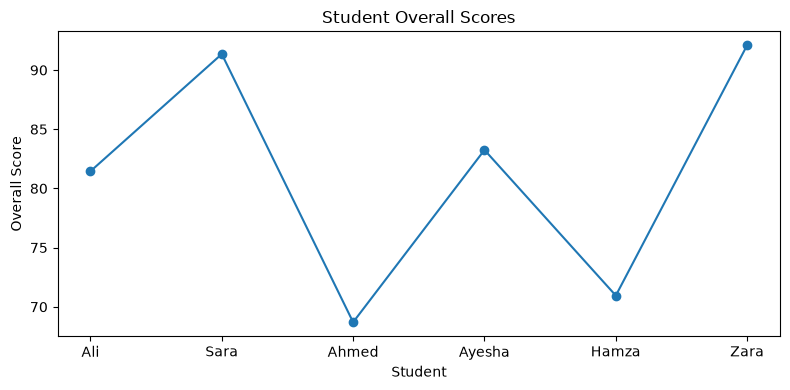

In [8]:
x = np.arange(len(students))

fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(x, overall_scores, marker="o")

ax.set_xticks(x)
ax.set_xticklabels(students)
ax.set_xlabel("Student")
ax.set_ylabel("Overall Score")
ax.set_title("Student Overall Scores")

plt.tight_layout()
plt.show()


## 9. Distribution of scores

A histogram lets us see how the final scores are distributed.


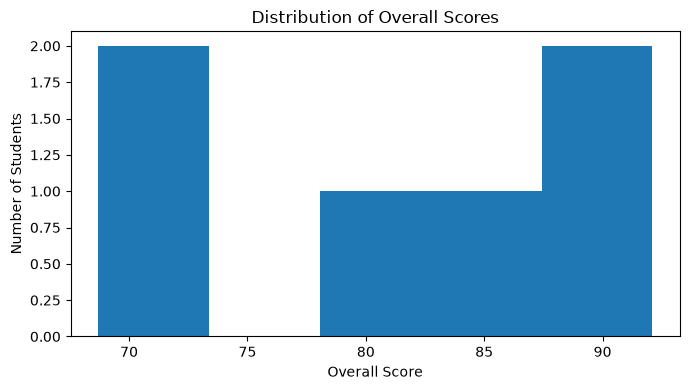

In [9]:
fig, ax = plt.subplots(figsize=(7, 4))

ax.hist(overall_scores, bins=5)

ax.set_xlabel("Overall Score")
ax.set_ylabel("Number of Students")
ax.set_title("Distribution of Overall Scores")

plt.tight_layout()
plt.show()


## 10. Compare study hours with overall score

We add one simple variable: study hours per week.

A scatter plot lets us visually inspect whether students who studied more tended to have higher scores.


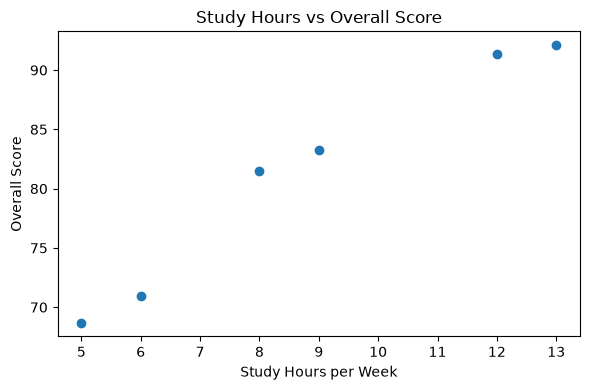

Study hours: [ 8 12  5  9  6 13]
Overall scores: [81.45 91.35 68.7  83.25 70.95 92.1 ]


In [10]:
study_hours = np.array([8, 12, 5, 9, 6, 13])

fig, ax = plt.subplots(figsize=(6, 4))

ax.scatter(study_hours, overall_scores)

ax.set_xlabel("Study Hours per Week")
ax.set_ylabel("Overall Score")
ax.set_title("Study Hours vs Overall Score")

plt.tight_layout()
plt.show()

print("Study hours:", study_hours)
print("Overall scores:", np.round(overall_scores, 2))


## 11. See the whole score matrix as an image

Each row is a student and each column is a subject.


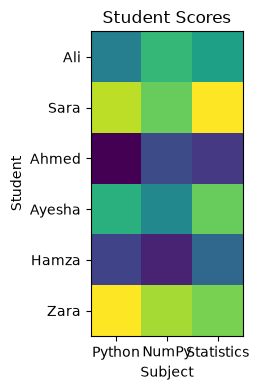

In [17]:
fig, ax = plt.subplots(figsize=(6, 4))

ax.imshow(scores)

ax.set_xticks(range(len(subjects)))
ax.set_xticklabels(subjects)

ax.set_yticks(range(len(students)))
ax.set_yticklabels(students)

ax.set_xlabel("Subject")
ax.set_ylabel("Student")
ax.set_title("Student Scores")

plt.tight_layout()
plt.show()


## 12. Final mini report

The important part is that there is no special ML library doing the calculations for us. We used basic arrays, statistics, matrix multiplication, and plots.


In [12]:
print("===== STUDENT PERFORMANCE REPORT =====")
print()

for i in range(len(students)):
    print(
        students[i],
        "| average:", round(float(student_mean[i]), 2),
        "| overall:", round(float(overall_scores[i]), 2)
    )

print()
print("Top student:", top_student)
print("Top score:", round(float(top_score), 2))
print("Class mean:", round(float(np.mean(overall_scores)), 2))
print("Class median:", round(float(np.median(overall_scores)), 2))


===== STUDENT PERFORMANCE REPORT =====

Ali | average: 81.67 | overall: 81.45
Sara | average: 91.67 | overall: 91.35
Ahmed | average: 69.0 | overall: 68.7
Ayesha | average: 83.67 | overall: 83.25
Hamza | average: 71.33 | overall: 70.95
Zara | average: 91.67 | overall: 92.1

Top student: Zara
Top score: 92.1
Class mean: 81.3
Class median: 82.35


### NumPy
- `np.array`
- `.shape`
- `.ndim`
- `.size`
- indexing and slicing
- `np.mean`
- `np.median`
- `np.std`
- `np.min`
- `np.max`
- `np.unique`
- `np.argmax`
- `@` matrix multiplication
- `np.round`
- `np.arange`

### Matplotlib
- `plt.subplots`
- `ax.plot`
- `ax.hist`
- `ax.scatter`
- `ax.imshow`
- axis labels
- titles
- `plt.show`


```text
scores
   ↓
NumPy matrix
   ↓
scores @ weights
   ↓
weighted result
   ↓
statistics + visualization
```

## The main lesson

I did not need a large dataset or a machine-learning framework to practice NumPy.

I took a small matrix and learned how to:

**store → inspect → slice → calculate → multiply → summarize → visualize**
